**14/08/2026** -- Figure 3: Contributions of local and transported fire pollution to fire PM2.5 concentrations.

Data for 2000-2022.

In [1]:
Sys.setenv(PROJ_DATA = "/home/users/cho00/miniconda3/envs/ppca/share/proj")

In [15]:
library(dplyr)
library(readr)
library(dtplyr)
library(tidyr)
library(sf)
library(ggplot2)
library(patchwork)
# library(cowplot)

In [17]:
root <- rprojroot::find_root(rprojroot::has_file(".gitignore"))
source(file.path(root, "src/deprivation_pm_bhm/plotting.R"))    # plot_map() wrapper of ggplot() + geom_sf()

In [19]:
SCRATCH_DIR <- Sys.getenv("SCRATCH_DIR")
DATA_PATH   <- file.path(SCRATCH_DIR, 
                         "data/spatial/fire_pm_dep_paper_data",
                         "proc_data/df_af_annual_loc_tp_2000_2023.csv")
NAT_BOUNDS_PATH     <- file.path(SCRATCH_DIR, 
                         "data/spatial/nat_boundaries",
                         "WB_countries_Admin0_10m")
western_sahara_path <- file.path(SCRATCH_DIR, 
                         "data/spatial/nat_boundaries",
                         "western_sahara/gadm41_ESH_0.shp")

In [20]:
nat_bounds <- sf::read_sf(NAT_BOUNDS_PATH) |> 
    filter(CONTINENT == "Africa")

In [21]:
esh_bounds <- sf::read_sf(western_sahara_path)

In [5]:
df <- read_csv(DATA_PATH)

Rows: 994412 Columns: 107
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (11): geometry, ISO_A3, country, region, continent, INCOME_GRP, ECONOMY,...
dbl (96): lon, lat, total_PM25, total_O3, fire_PM25, fire_O3, fire_PM25_hu, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [11]:
# Compute mean across all years 2000-2023
df_avg <- lazy_dt(df) %>% 
    filter(year <= 2022) |>
    select(c("attr_fire_PM25_emis_0_100km", "attr_fire_PM25_emis_100_2000km",
             "bc_attr_fire_PM25_emis_0_100km", "bc_attr_fire_PM25_emis_100_2000km",
             "frac_fire_PM25_emis_0_100km", "frac_fire_PM25_emis_100_2000km",
             "lon", "lat", "geometry", "country", "ISO_A3", "region", 
             "pop_count", "fire_PM25_hu", "fire_PM25")) %>% 
    group_by(lon, lat) %>% 
    summarise(
        across( c("geometry", "country", "ISO_A3", "region"), ~ first(.x) ),
        across( c("pop_count", "fire_PM25", "fire_PM25_hu"), ~ mean(.x, na.rm = TRUE) ),
        across( c('attr_fire_PM25_emis_0_100km', 'attr_fire_PM25_emis_100_2000km'), ~ mean(.x, na.rm = TRUE) ),
        across( c('bc_attr_fire_PM25_emis_0_100km', 'bc_attr_fire_PM25_emis_100_2000km'), ~ mean(.x, na.rm = TRUE) ),
        across( c('frac_fire_PM25_emis_0_100km', 'frac_fire_PM25_emis_100_2000km'), ~ mean(.x, na.rm = TRUE) ),
        .groups = "drop"
    ) %>% 
    as_tibble()

In [12]:
# Convert to sf
map_sf <- df_avg %>% 
    mutate(geometry = sf::st_as_sfc(geometry)) %>% 
    sf::st_as_sf(crs = 4326)

In [13]:
options(repr.plot.width=15, repr.plot.height=8, repr.plot.quality=450)

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


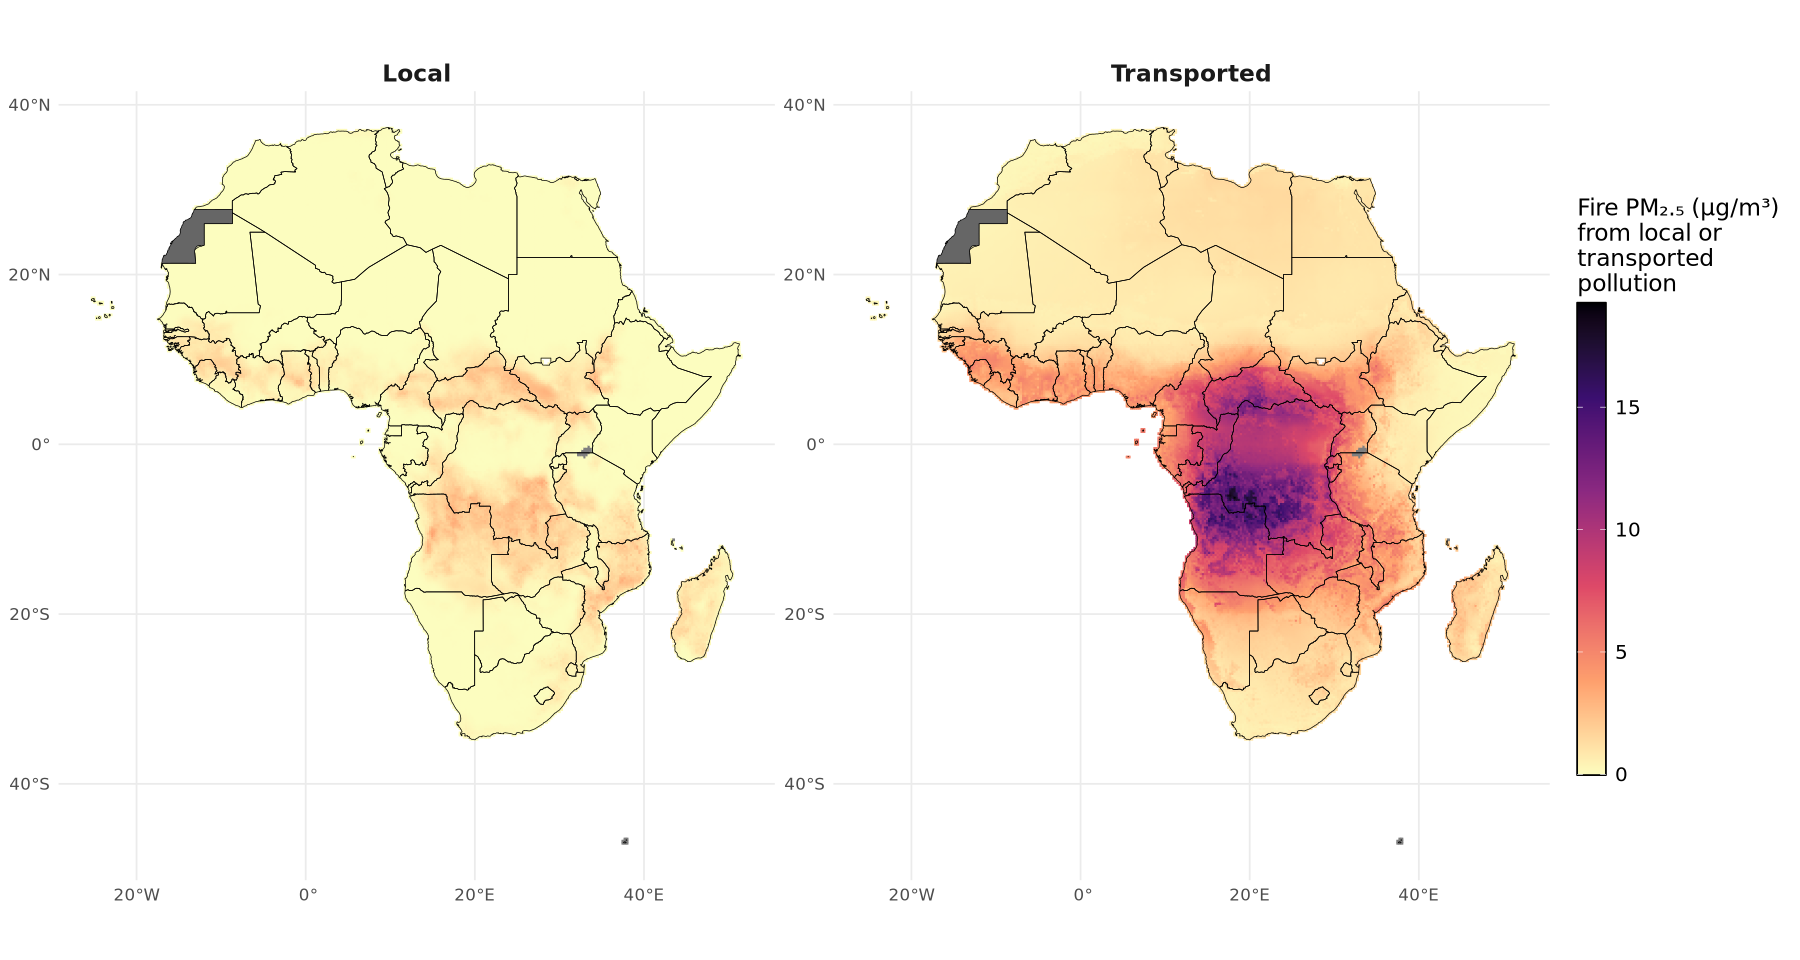

In [25]:
# Select attributable PM columns
plot_data <- map_sf

# Pivot to long form
plot_data <- plot_data %>%
    pivot_longer(
        cols = starts_with("bc_attr_fire_PM25_emis_"),
        names_to = "distance_bin",
        values_to = "bc_attr_fire_PM25"
    ) %>% 
    mutate(distance_bin = sub("bc_attr_fire_PM25_emis_", "", distance_bin)) %>% 
    mutate(distance_bin = sub("_", "-", distance_bin) )

# Correct order of bins for facet grid
ordered_bins <- c("0-100km", "100-2000km")

# Set factor levels for ordering distance bins
plot_data$distance_bin <- factor(
    plot_data$distance_bin,
    levels = ordered_bins
)

# Update 22/01: set facet labels to 'Local' and 'Transported'
plot_data$distance_label <- factor(
    case_when(
        plot_data$distance_bin == "0-100km" ~ "Local",
        plot_data$distance_bin == "100-2000km" ~ "Transported",
        .default = NA_character_
    ),
    levels = c("Local", "Transported")
)


# Plot facet grid of maps (panel for each emissions band)
bc_attr_by_band_100km <- plot_map(
    data = plot_data,
    color = "bc_attr_fire_PM25",
    fill = "bc_attr_fire_PM25",
    name = "Fire PM₂.₅\n(μg/m³)",
    # palette = "YlOrRd",
    palette = "Reds",
    nat_bounds_sf = nat_bounds,
    nat_bounds_color = "black",
    nat_bounds_size = 0.3,
    facet_var = "distance_label",
    strip_text_size = 14,
    strip_text_face = "bold",
    legend_title_text_face = "plain",
    legend_title_text_size = 14,
    legend_text_size = 12,
    facet_ncol = 3
) + 
    scale_fill_viridis_c(
        option = "magma",
        direction = -1,
        name = "Fire PM₂.₅ (μg/m³)\nfrom local or\ntransported\npollution",
        guide = guide_colorbar(ticks.colour = "white", 
                               frame.colour = "black"),
    ) +
    scale_colour_viridis_c(
        option = "magma",
        direction = -1,
        name = "Fire PM₂.₅ (μg/m³)\nfrom local or\ntransported\npollution",
        guide = guide_colorbar(ticks.colour = "white", 
                               frame.colour = "black"),
    ) +
    geom_sf(data = esh_bounds, color = "black", fill = "gray40")
    

bc_attr_by_band_100km

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


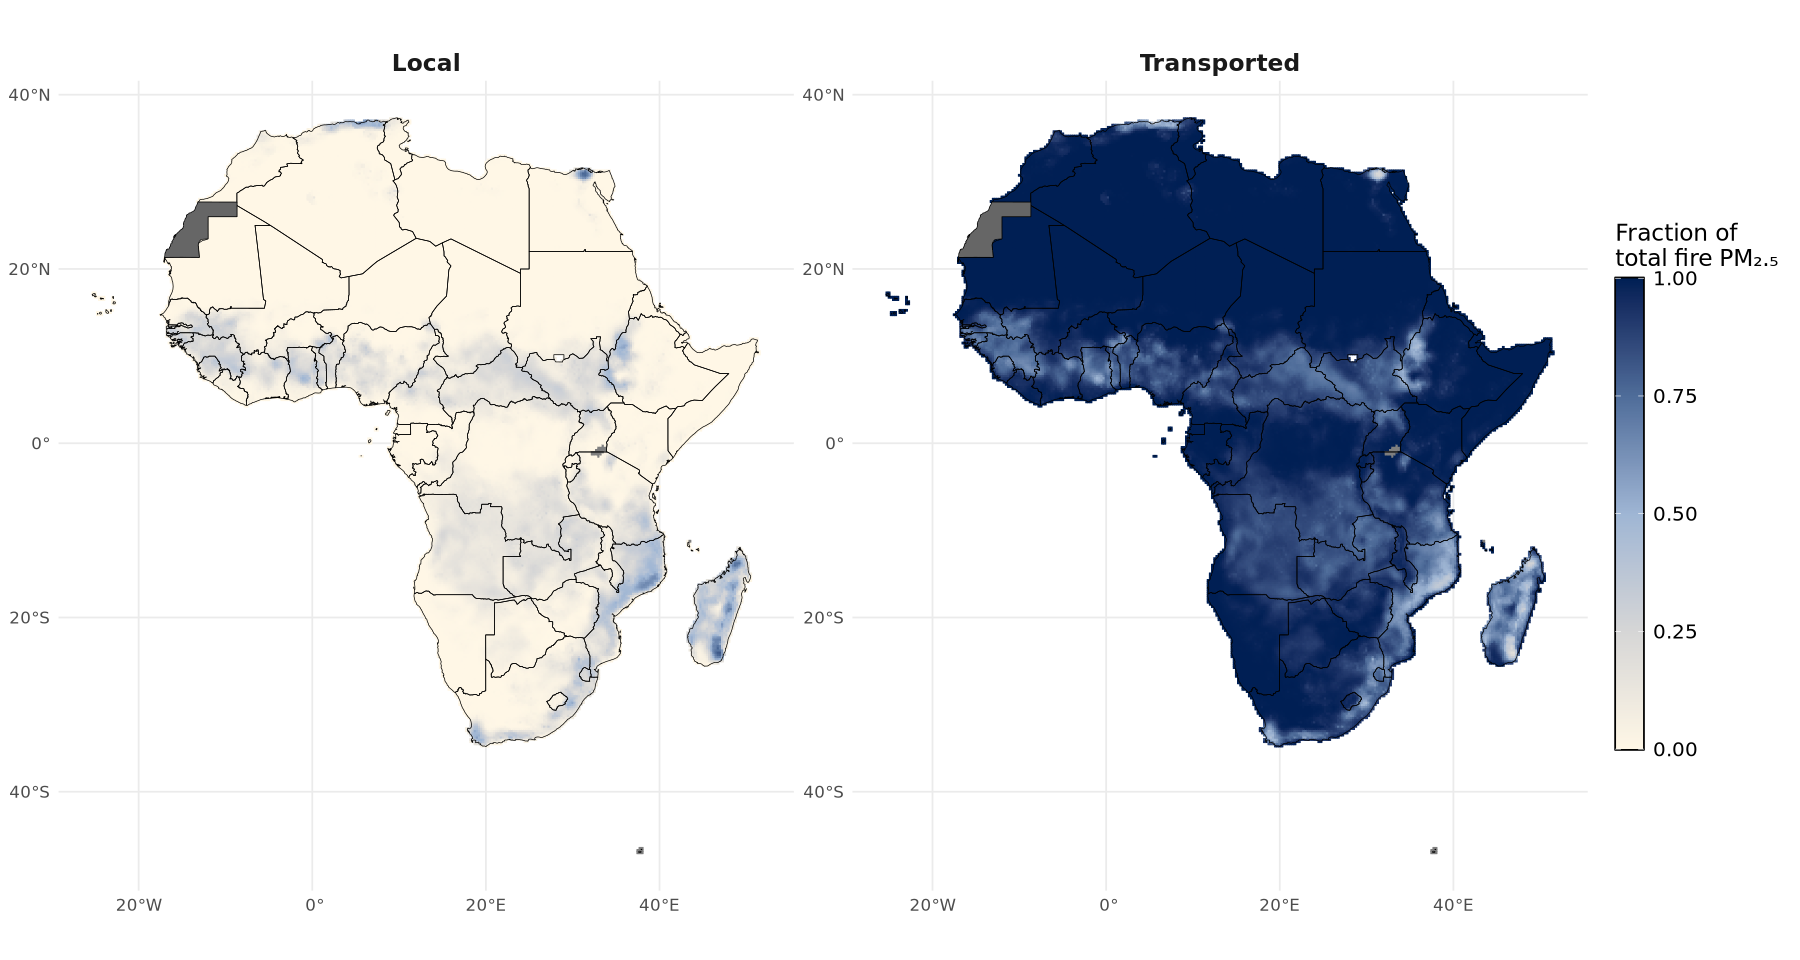

In [26]:
# Select attributable fraction columns
plot_data <- map_sf

# Pivot to long form
plot_data <- plot_data %>%
    pivot_longer(
        cols = starts_with("frac_fire_PM25_emis_"),
        names_to = "distance_bin",
        values_to = "frac_fire_PM25"
    ) %>% 
    mutate(distance_bin = sub("frac_fire_PM25_emis_", "", distance_bin)) %>% 
    mutate(distance_bin = sub("_", "-", distance_bin) )

# Correct order of bins for facet grid
ordered_bins <- c("0-100km", "100-2000km")

# Set factor levels for ordering distance bins
plot_data$distance_bin <- factor(
    plot_data$distance_bin,
    levels = ordered_bins
)

# Update 22/01: set facet labels to 'local' and 'transported'
plot_data$distance_label <- factor(
    case_when(
        plot_data$distance_bin == "0-100km" ~ "Local",
        plot_data$distance_bin == "100-2000km" ~ "Transported",
        .default = NA_character_
    ),
    levels = c("Local", "Transported")
)

# Plot facet grid of maps (panel for each emissions band)
frac_by_band_100km <- plot_map(
    data = plot_data,
    color = "frac_fire_PM25",
    fill = "frac_fire_PM25",
    name = "Fraction of\ntotal\nfire PM₂.₅",
    palette = "Spectral", 
    nat_bounds_sf = nat_bounds,
    facet_var = "distance_label",
    strip_text_size = 14,
    strip_text_face = "bold",
    legend_title_text_face = "plain",
    legend_title_text_size = 14,
    legend_text_size = 12,
    direction = -1,
    facet_ncol = 3,
    limits = c(0, 1 + 1e-10) # limits (0,1) but add epsilon to cover floating point errors when adding band fractions   #nolint
) + 
    scale_fill_gradientn(
        colours = c(
            "#FFF7E6",
            "#D6D6D6",
            "#9FB6D4",
            "#4F6D9A",
            "#001F54"
        ),
        values  = c(0, 0.25, 0.5, 0.75, 1),
        limits  = c(0, 1),
        name    = "Fraction of\ntotal fire PM₂.₅",
        guide   = guide_colorbar(ticks.colour = "white", 
                            frame.colour = "black"),
    ) +
    scale_colour_gradientn(
        colours = c(
            "#FFF7E6",
            "#D6D6D6",
            "#9FB6D4",
            "#4F6D9A",
            "#001F54"
        ),
        values  = c(0, 0.25, 0.5, 0.75, 1),
        limits  = c(0, 1),
        name    = "Fraction of\ntotal fire PM₂.₅",
        guide   = guide_colorbar(ticks.colour = "white", 
                            frame.colour = "black"),
    ) +
    geom_sf(data = esh_bounds, color = "black", fill = "gray40")

frac_by_band_100km

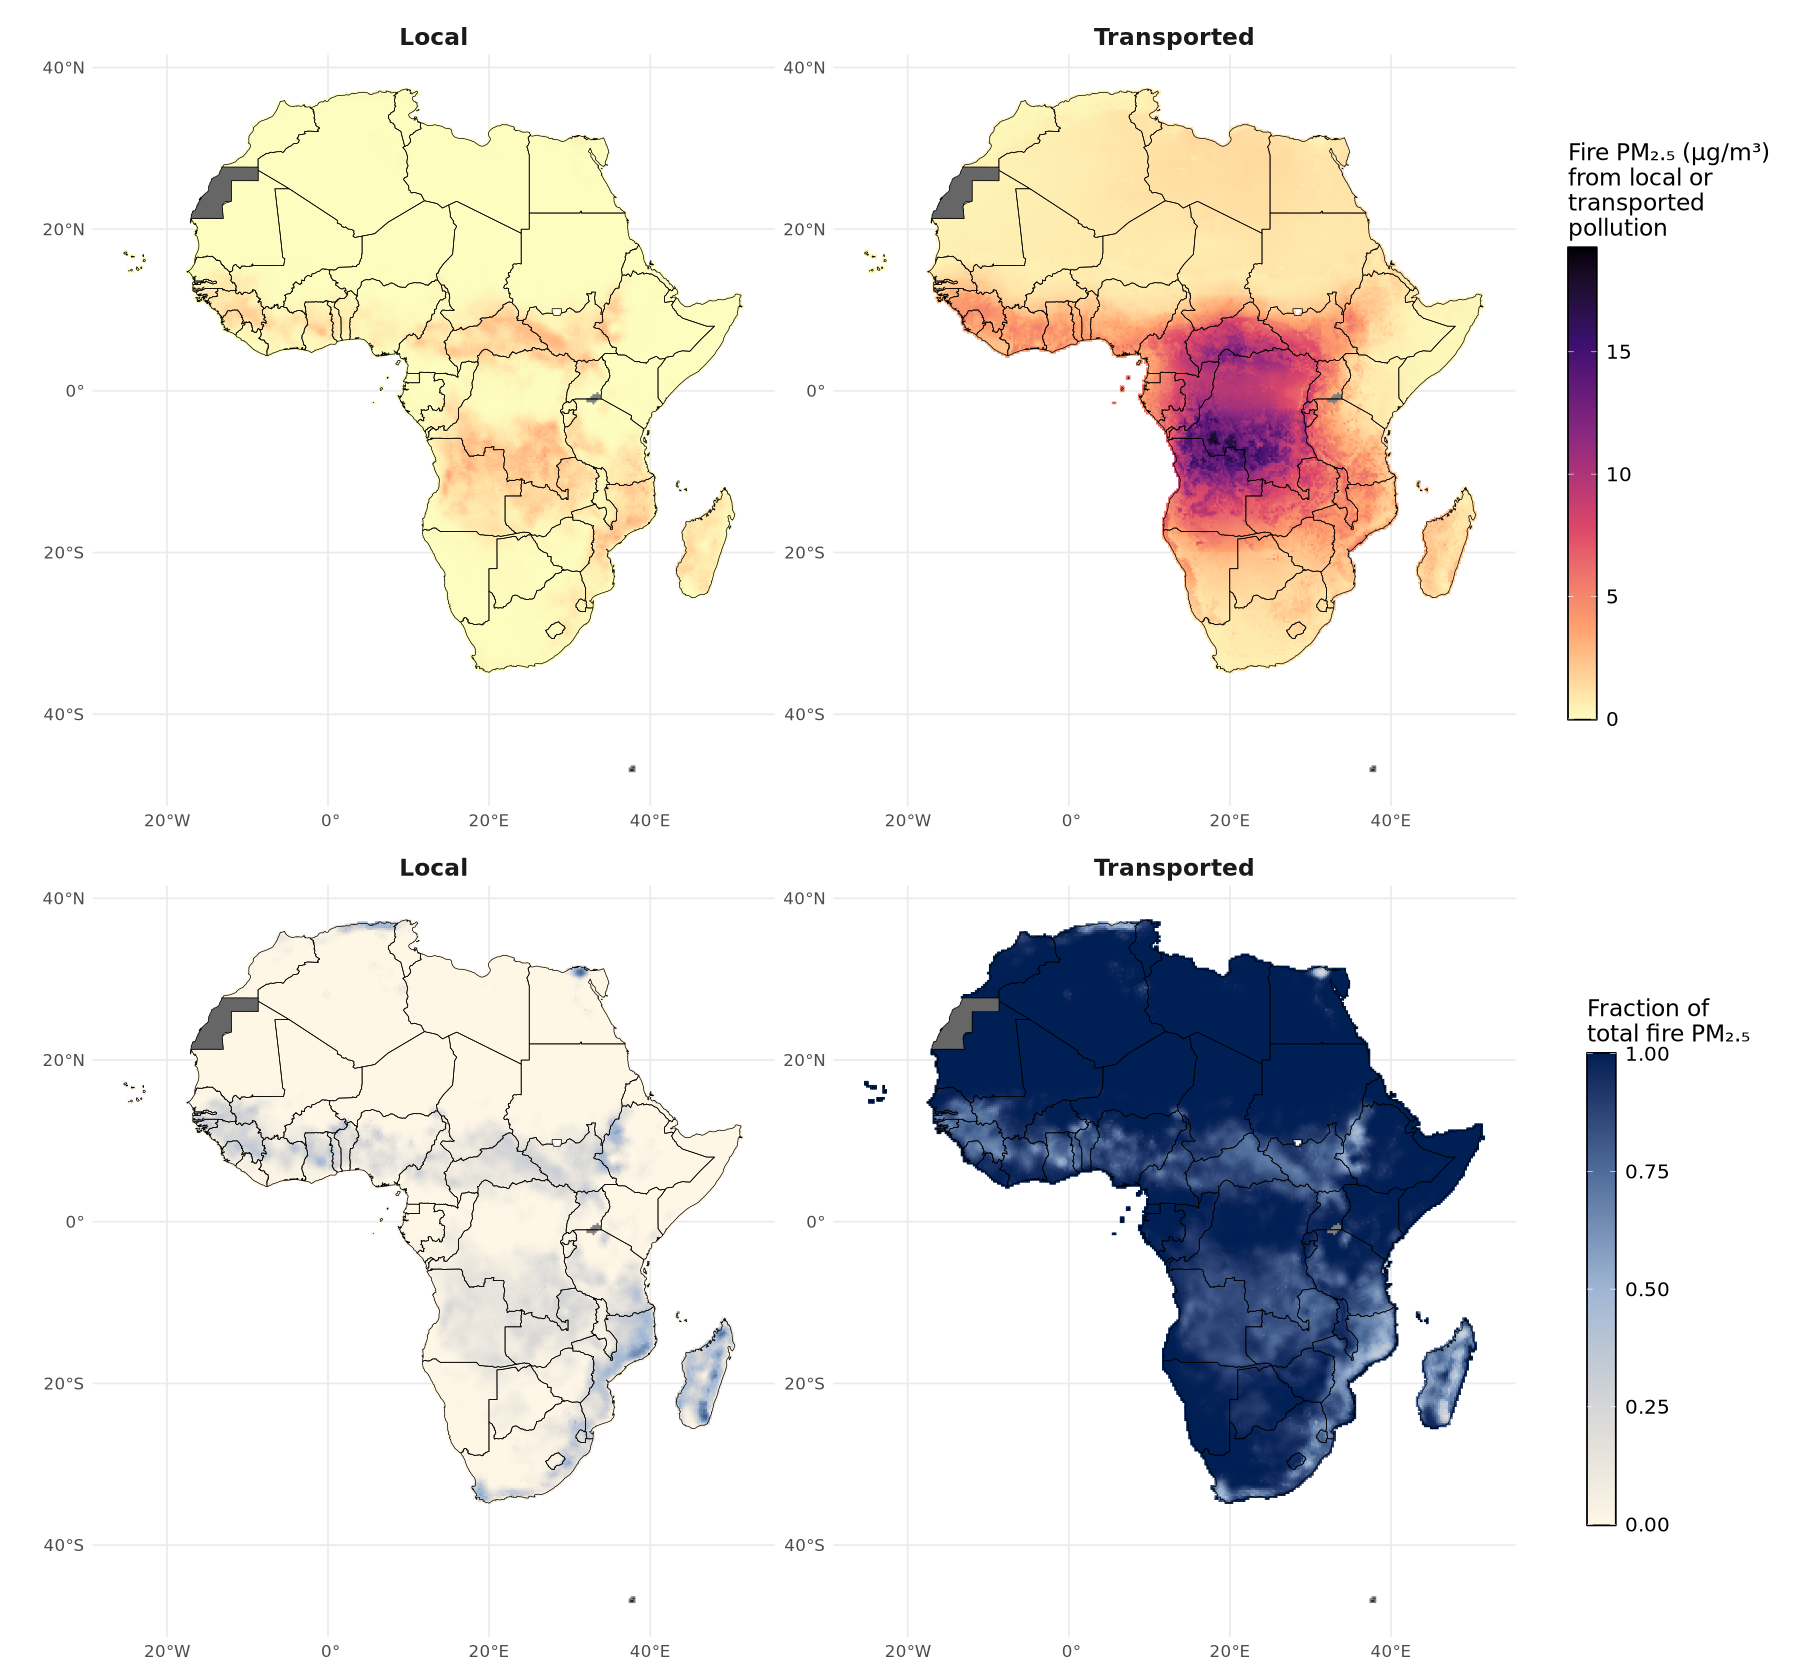

In [27]:
options(repr.plot.width = 15, repr.plot.height = 14, repr.plot.quality = 450)
attributable_pm_frac_panel <- bc_attr_by_band_100km  / frac_by_band_100km
attributable_pm_frac_panel

In [28]:
ggsave(
    plot = attributable_pm_frac_panel,
    filename = file.path(root, "paper_results/figures/fig_3.png"),
    width = 15,
    height = 14,
    dpi = 450,
    bg = "white"
)